#Worksheet 6

Shreeya Bogati

In [3]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import zipfile, os, random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import (Conv2D, BatchNormalization, Activation,
                                     MaxPooling2D, Dropout, Flatten, Dense,
                                     GlobalAveragePooling2D)
from tensorflow.keras.models import Model
from tensorflow.keras.applications import VGG16
from tensorflow.keras.optimizers import Adam
from PIL import Image, UnidentifiedImageError
from sklearn.metrics import classification_report

zip_path  = '/content/drive/MyDrive/AI and machine learning/FruitinAmazon.zip'
with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall('./')

train_dir = '/content/FruitinAmazon/train'
test_dir  = '/content/FruitinAmazon/test'
print("Extraction complete.")
print("Train:", os.listdir(train_dir))


Extraction complete.
Train: ['cupuacu', 'tucuma', 'acai', 'pupunha', 'guarana', 'graviola']


## Section 2.1 – Data Understanding and Visualizations

### Step 1 – Read dataset directory & extract class names

In [5]:
class_names = sorted(os.listdir(train_dir))
if not class_names:
    print("No class directories found in the train folder!")
else:
    print(f"Found {len(class_names)} classes: {class_names}")


Found 6 classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


### Step 2 – Check for corrupted images

In [6]:
corrupted_images = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            try:
                with Image.open(img_path) as img:
                    img.verify()
            except (IOError, UnidentifiedImageError):
                corrupted_images.append(img_path)

if corrupted_images:
    print("\nCorrupted Images Found:")
    for img in corrupted_images:
        print(img)
else:
    print("No corrupted images found.")


No corrupted images found.


### Step 3 – Check class balance

In [7]:
class_counts = {}

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        images = [f for f in os.listdir(class_path)
                  if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        class_counts[class_name] = len(images)

print("\nClass Distribution:")
print("=" * 45)
print(f"{'Class Name':<25}{'Valid Image Count':>15}")
print("=" * 45)
for cls, cnt in class_counts.items():
    print(f"{cls:<25}{cnt:>15}")
print("=" * 45)



Class Distribution:
Class Name               Valid Image Count
acai                                  15
cupuacu                               15
graviola                              15
guarana                               15
pupunha                               15
tucuma                                15


### Step 4 – Visualise one random image per class

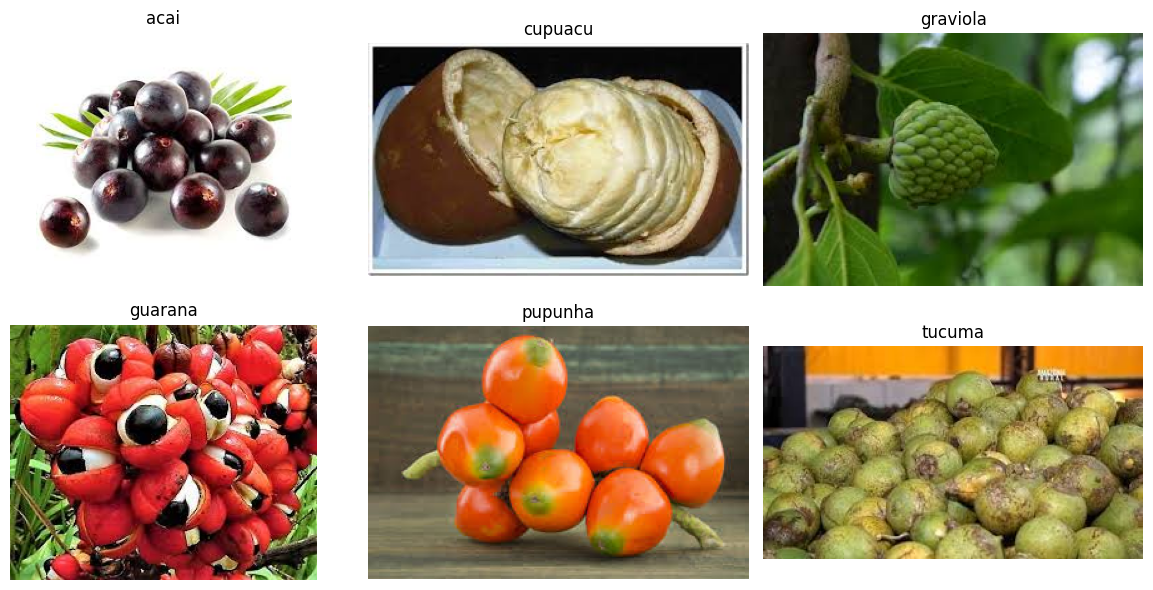

In [8]:
selected_images, selected_labels = [], []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        images = [f for f in os.listdir(class_path)
                  if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        if images:
            selected_images.append(os.path.join(class_path, random.choice(images)))
            selected_labels.append(class_name)

num_classes = len(selected_images)
cols = (num_classes + 1) // 2
rows = 2

fig, axes = plt.subplots(rows, cols, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    if i < num_classes:
        img = mpimg.imread(selected_images[i])
        ax.imshow(img)
        ax.set_title(selected_labels[i])
        ax.axis("off")
    else:
        ax.axis("off")
plt.tight_layout()
plt.show()


## Section 2.2 – Data Generation and Pre-processing

### Step 1 – Load train/validate datasets


In [9]:
IMAGE_SIZE  = (224, 224)
BATCH_SIZE  = 32

train_ds, val_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="both",
    seed=1337,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
)

# Inspect a batch
for images, labels in train_ds.take(1):
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)


Found 90 files belonging to 6 classes.
Using 72 files for training.
Using 18 files for validation.
Images shape: (32, 224, 224, 3)
Labels shape: (32,)


### Step 2 – Visualise a batch from train_ds

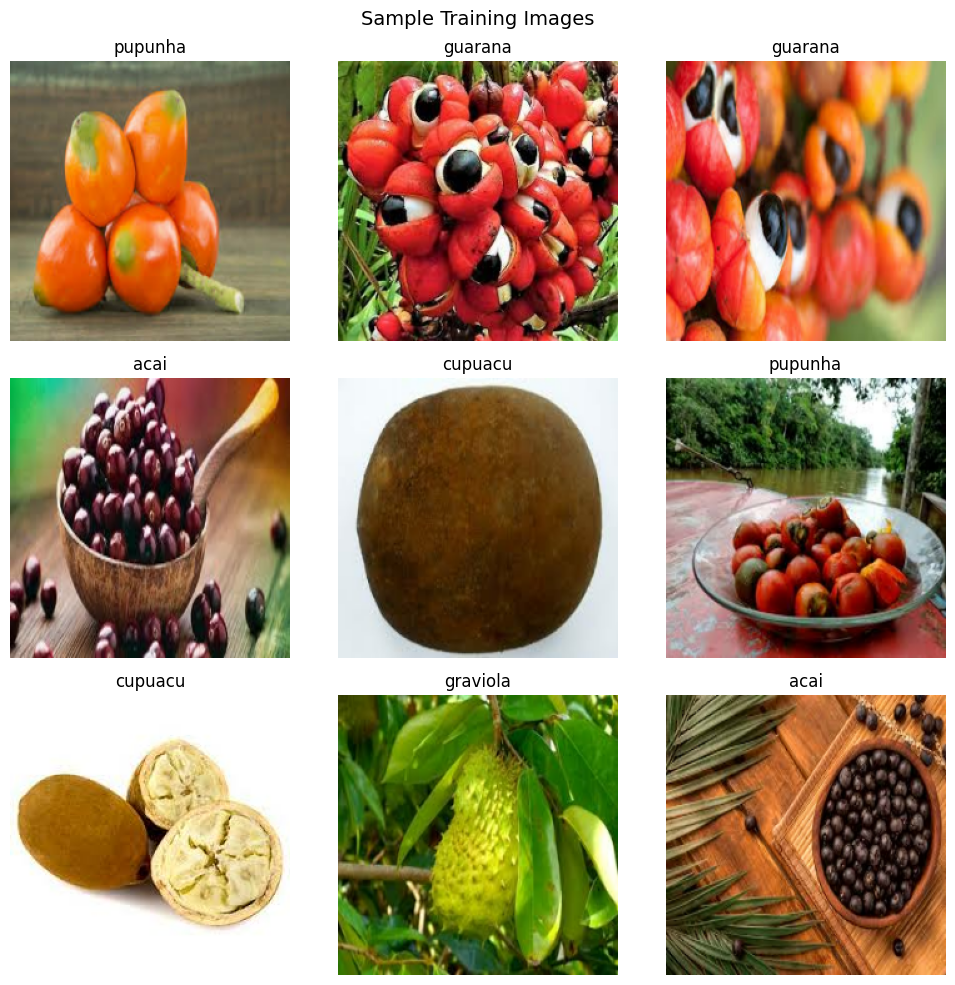

In [10]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(np.array(images[i]).astype("uint8"))
        plt.title(class_names[int(labels[i])])
        plt.axis("off")
plt.suptitle("Sample Training Images", fontsize=14)
plt.tight_layout()
plt.show()


### Step 3 – Define data augmentation

In [11]:
data_augmentation_layers = [
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomBrightness(0.1),
]

def data_augmentation(images):
    for layer in data_augmentation_layers:
        images = layer(images)
    return images


### Step 4 – Visualise augmented images

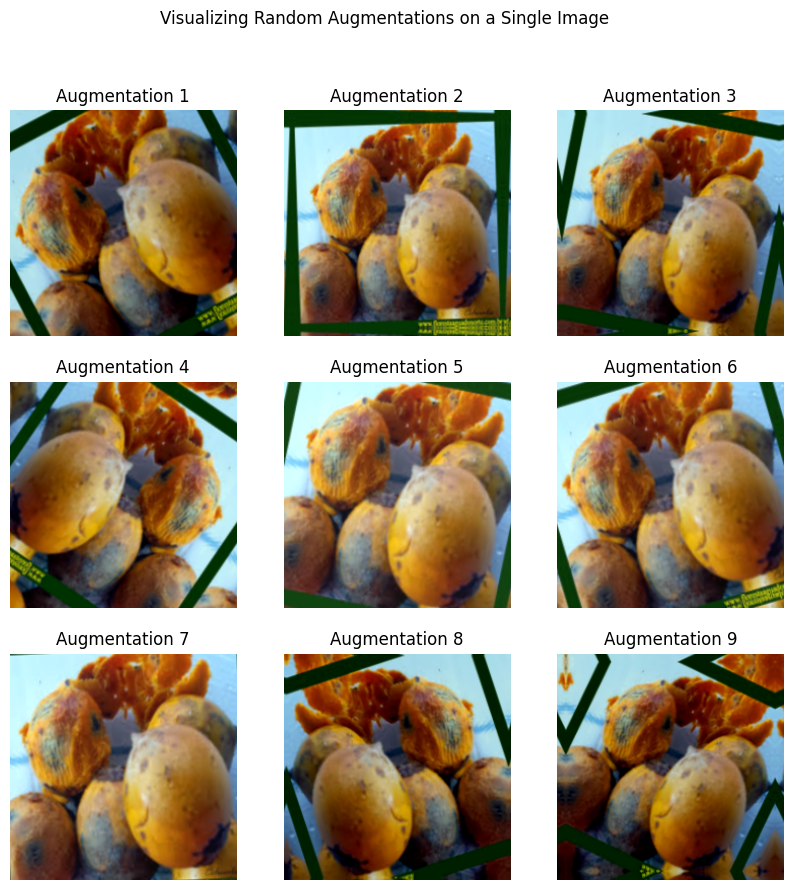

In [13]:
# 1. Take one batch from the training dataset
plt.figure(figsize=(10, 10))
for images, _ in train_ds.take(1):
    # Select the first image from the batch
    first_image = images[0]

    for i in range(9):
        # 2. Apply augmentation to the same image
        # We add a dimension using [tf.newaxis] because the layer expects a batch
        augmented_image = data_augmentation(tf.expand_dims(first_image, 0))

        # 3. Plot the result
        ax = plt.subplot(3, 3, i + 1)
        # Convert to uint8 for display (undoing normalization if necessary)
        plt.imshow(augmented_image[0].numpy().astype("uint8"))
        plt.title(f"Augmentation {i+1}")
        plt.axis("off")

plt.suptitle("Visualizing Random Augmentations on a Single Image")
plt.show()

## Task 1 – Improved CNN with BatchNormalization & Dropout
Building on Worksheet-5 but with:
- Data Augmentation (inside the model – recommended practice)
- Deeper architecture
- BatchNormalization after every Conv / Dense block
- Dropout for regularisation
- 224×224 input instead of 128×128


### Build the model

In [14]:
input_shape = (224, 224, 3)
num_classes = len(class_names)   # 6 fruit classes

inputs = keras.Input(shape=input_shape)

# ── Augmentation + Rescaling (only active during training) ────────────────────
x = data_augmentation(inputs)
x = layers.Rescaling(1./255)(x)

# ── Conv Block 1 ──────────────────────────────────────────────────────────────
x = Conv2D(32, (3, 3), padding='same', activation=None)(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = MaxPooling2D((2, 2))(x)
x = Dropout(0.25)(x)

# ── Conv Block 2 ──────────────────────────────────────────────────────────────
x = Conv2D(64, (3, 3), padding='same', activation=None)(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = MaxPooling2D((2, 2))(x)
x = Dropout(0.25)(x)

# ── Conv Block 3 ──────────────────────────────────────────────────────────────
x = Conv2D(128, (3, 3), padding='same', activation=None)(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = MaxPooling2D((2, 2))(x)
x = Dropout(0.25)(x)

# ── Conv Block 4 ──────────────────────────────────────────────────────────────
x = Conv2D(256, (3, 3), padding='same', activation=None)(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = MaxPooling2D((2, 2))(x)
x = Dropout(0.25)(x)

# ── Flatten + FC Layers ───────────────────────────────────────────────────────
x = Flatten()(x)

x = Dense(512, activation=None)(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = Dropout(0.5)(x)

x = Dense(256, activation=None)(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = Dropout(0.5)(x)

x = Dense(128, activation=None)(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = Dropout(0.5)(x)

# ── Output Layer ──────────────────────────────────────────────────────────────
outputs = Dense(num_classes, activation='softmax')(x)

model_scratch = keras.Model(inputs=inputs, outputs=outputs, name="CNN_from_scratch")
model_scratch.summary()


Model: "CNN_from_scratch"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_brightness               │ (None, 224, 224, 3)    │             0 │
│ (RandomBrightness)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 26,249,542 (100.13 MB)

 Trainable params: 26,246,790 (100.12 MB)

 Non-trainable params: 2,752 (10.75 KB)

### Compile the model

In [15]:
model_scratch.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


### Load test dataset

In [16]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    seed=123
)


Found 30 files belonging to 6 classes.


### Train the model

In [17]:
checkpoint_cb = keras.callbacks.ModelCheckpoint(
    'best_scratch_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

early_stop_cb = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

history_scratch = model_scratch.fit(
    train_ds,
    epochs=250,
    validation_data=val_ds,
    callbacks=[checkpoint_cb, early_stop_cb]
)


Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.1100 - loss: 3.0325
Epoch 1: val_accuracy improved from None to 0.22222, saving model to best_scratch_model.keras

Epoch 1: finished saving model to best_scratch_model.keras
3/3 ━━━━━━━━━━━━━━━━━━━━ 31s 7s/step - accuracy: 0.1111 - loss: 2.8996 - val_accuracy: 0.2222 - val_loss: 1.7968
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.1545 - loss: 2.6382
Epoch 2: val_accuracy did not improve from 0.22222
3/3 ━━━━━━━━━━━━━━━━━━━━ 19s 5s/step - accuracy: 0.1667 - loss: 2.5623 - val_accuracy: 0.2222 - val_loss: 1.7369
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.2535 - loss: 1.9234
Epoch 3: val_accuracy did not improve from 0.22222
3/3 ━━━━━━━━━━━━━━━━━━━━ 22s 6s/step - accuracy: 0.2917 - loss: 1.8816 - val_accuracy: 0.2222 - val_loss: 1.7986
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.2986 - loss: 2.1137
Epoch 4: val_accuracy did not improve from 0.22222
3/3 ━━━━━━━━━━━━━━━━━━━━ 1

### Plot training curves

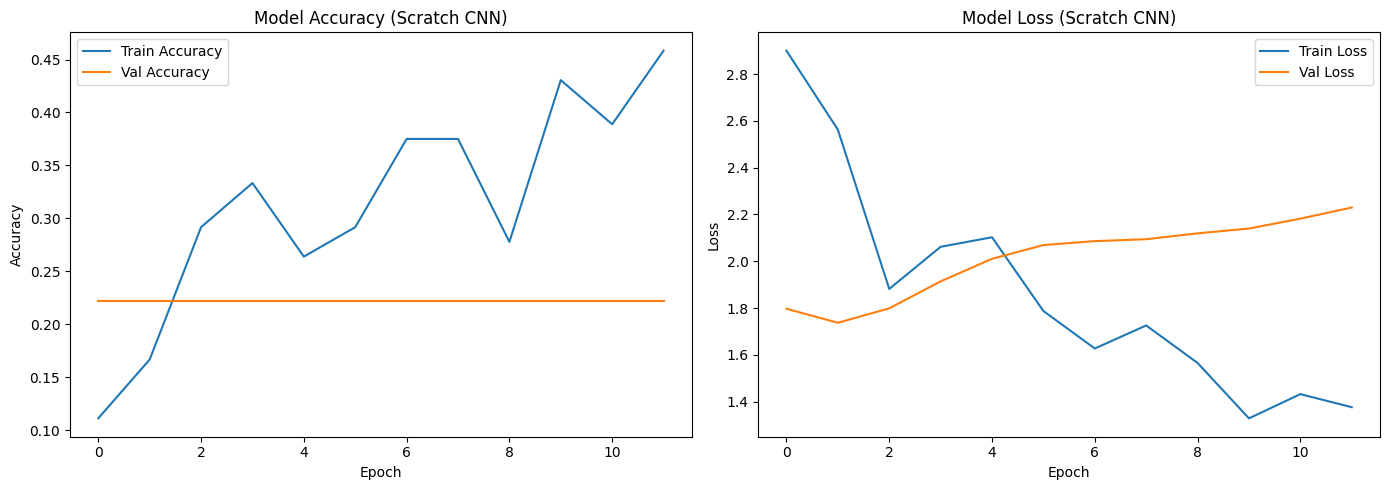

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_scratch.history['accuracy'],     label='Train Accuracy')
axes[0].plot(history_scratch.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Model Accuracy (Scratch CNN)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history_scratch.history['loss'],     label='Train Loss')
axes[1].plot(history_scratch.history['val_loss'], label='Val Loss')
axes[1].set_title('Model Loss (Scratch CNN)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()


### Evaluate on test set

In [19]:
test_loss, test_acc = model_scratch.evaluate(test_ds)
print(f"Scratch CNN  –  Test Loss: {test_loss:.4f}  |  Test Accuracy: {test_acc:.4f}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.1667 - loss: 1.7816
Scratch CNN  –  Test Loss: 1.7816  |  Test Accuracy: 0.1667


### Save the scratch model

In [20]:
model_scratch.save('cnn_scratch_ws6.keras')
print("Scratch model saved as cnn_scratch_ws6.keras")


Scratch model saved as cnn_scratch_ws6.keras


### Classification report – scratch CNN

In [21]:
y_true_s, y_pred_s = [], []
for images, labels in test_ds:
    preds = model_scratch.predict(images, verbose=0)
    y_pred_s.extend(np.argmax(preds, axis=1))
    y_true_s.extend(labels.numpy())

print("Classification Report – Scratch CNN")
print(classification_report(y_true_s, y_pred_s, target_names=class_names))


Classification Report – Scratch CNN
              precision    recall  f1-score   support

        acai       0.00      0.00      0.00         5
     cupuacu       0.17      1.00      0.29         5
    graviola       0.00      0.00      0.00         5
     guarana       0.00      0.00      0.00         5
     pupunha       0.00      0.00      0.00         5
      tucuma       0.00      0.00      0.00         5

    accuracy                           0.17        30
   macro avg       0.03      0.17      0.05        30
weighted avg       0.03      0.17      0.05        30



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Task 2 – Transfer Learning with VGG16



### Step 1 – Prepare datasets for VGG16

In [22]:
from tensorflow.keras.applications.vgg16 import preprocess_input

def preprocess_vgg(image, label):
    image = tf.cast(image, tf.float32)
    image = preprocess_input(image)   # VGG16-specific normalisation
    return image, label

train_ds_vgg = train_ds.map(preprocess_vgg)
val_ds_vgg   = val_ds.map(preprocess_vgg)
test_ds_vgg  = test_ds.map(preprocess_vgg)


### Step 2 – Load VGG16 base (no top, frozen)

In [23]:
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze all base layers
for layer in base_model.layers:
    layer.trainable = False

print(f"VGG16 base layers: {len(base_model.layers)}")
print(f"Trainable layers : {sum(1 for l in base_model.layers if l.trainable)}")
base_model.summary()


VGG16 base layers: 19
Trainable layers : 0


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

### Step 3 – Add custom classification head

In [24]:
x = base_model.output
x = GlobalAveragePooling2D()(x)          # reduces (7,7,512) → (512,)
x = Dense(1024, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
outputs_vgg = Dense(num_classes, activation='softmax')(x)

model_vgg = Model(inputs=base_model.input, outputs=outputs_vgg, name="VGG16_TransferLearning")
model_vgg.summary()


Model: "VGG16_TransferLearning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 15,503,942 (59.14 MB)

 Trainable params: 789,254 (3.01 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

### Step 4 – Compile

In [25]:
model_vgg.compile(
    optimizer=Adam(learning_rate=1e-4),   # lower LR for fine-tuning
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


### Step 5 – Train (only the custom head layers update; VGG16 base is frozen)

In [ ]:
checkpoint_vgg = keras.callbacks.ModelCheckpoint(
    'best_vgg16_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

early_stop_vgg = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=16,
    restore_best_weights=True,
    verbose=1
)

history_vgg = model_vgg.fit(
    train_ds_vgg,
    epochs=200,
    validation_data=val_ds_vgg,
    callbacks=[checkpoint_vgg, early_stop_vgg]
)


Epoch 1/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.1453 - loss: 9.1067 
Epoch 1: val_accuracy improved from None to 0.27778, saving model to best_vgg16_model.keras

Epoch 1: finished saving model to best_vgg16_model.keras
3/3 ━━━━━━━━━━━━━━━━━━━━ 59s 18s/step - accuracy: 0.1389 - loss: 9.0386 - val_accuracy: 0.2778 - val_loss: 2.6614
Epoch 2/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - accuracy: 0.1944 - loss: 6.6627 
Epoch 2: val_accuracy improved from 0.27778 to 0.44444, saving model to best_vgg16_model.keras

Epoch 2: finished saving model to best_vgg16_model.keras
3/3 ━━━━━━━━━━━━━━━━━━━━ 82s 19s/step - accuracy: 0.2083 - loss: 6.3445 - val_accuracy: 0.4444 - val_loss: 2.3231
Epoch 3/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.2679 - loss: 6.2383 
Epoch 3: val_accuracy did not improve from 0.44444
3/3 ━━━━━━━━━━━━━━━━━━━━ 57s 18s/step - accuracy: 0.3194 - loss: 5.6131 - val_accuracy: 0.4444 - val_loss: 2.2679
Epoch 4/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - a

### Plot VGG16 training curves

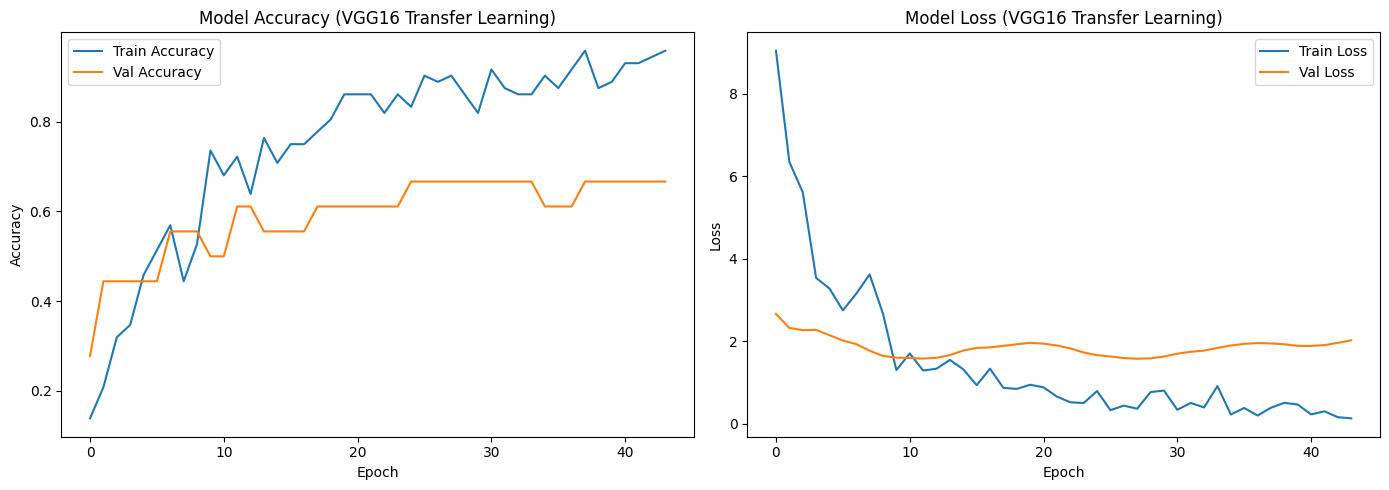

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_vgg.history['accuracy'],     label='Train Accuracy')
axes[0].plot(history_vgg.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Model Accuracy (VGG16 Transfer Learning)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history_vgg.history['loss'],     label='Train Loss')
axes[1].plot(history_vgg.history['val_loss'], label='Val Loss')
axes[1].set_title('Model Loss (VGG16 Transfer Learning)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()


### Evaluate VGG16 on test set

In [28]:
vgg_loss, vgg_acc = model_vgg.evaluate(test_ds_vgg)
print(f"VGG16 Transfer  –  Test Loss: {vgg_loss:.4f}  |  Test Accuracy: {vgg_acc:.4f}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 22s 22s/step - accuracy: 0.7000 - loss: 1.5826
VGG16 Transfer  –  Test Loss: 1.5826  |  Test Accuracy: 0.7000


### Inference output – predicted vs actual labels

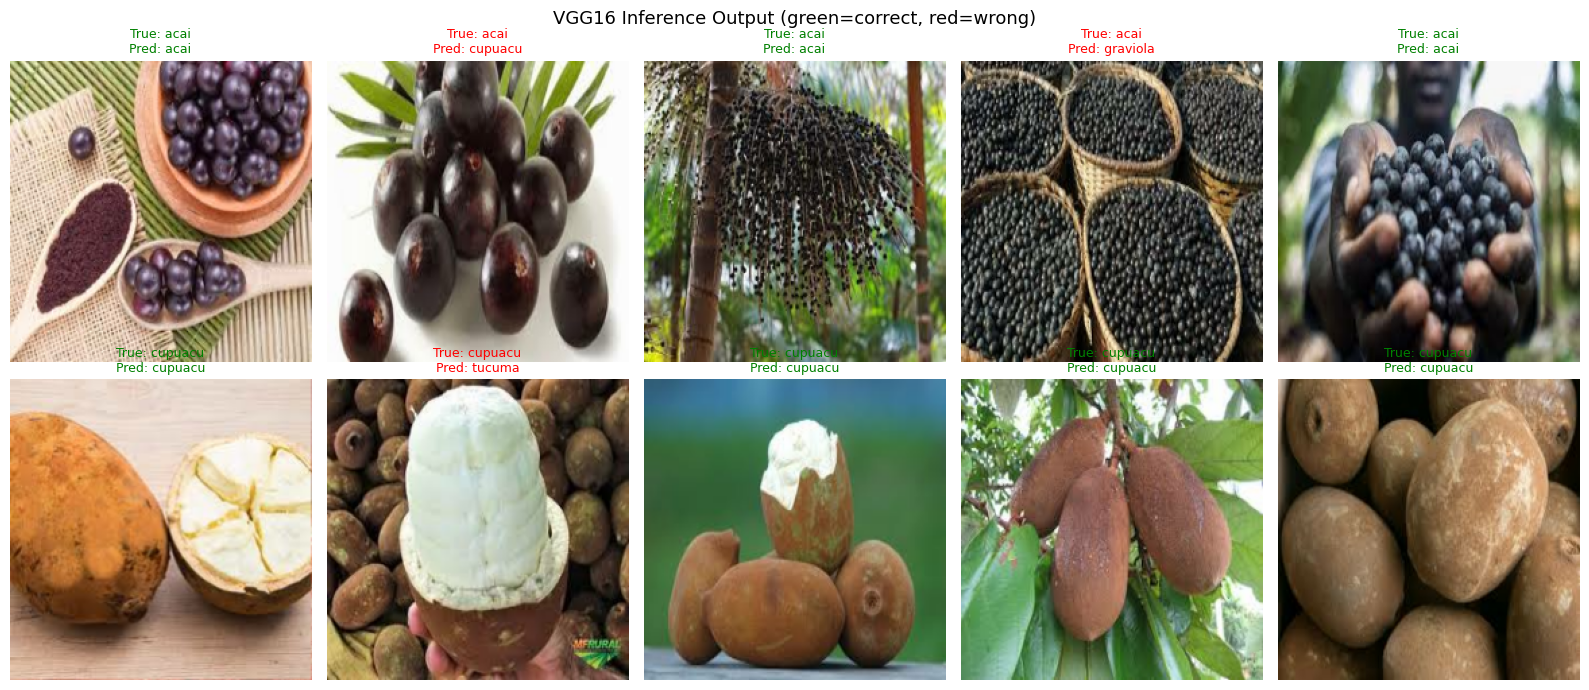

In [29]:
# Show a sample batch with predictions
for images_raw, labels in test_ds.take(1):
    images_proc, _ = preprocess_vgg(images_raw, labels)
    preds = model_vgg.predict(images_proc, verbose=0)
    pred_labels = np.argmax(preds, axis=1)

    fig, axes = plt.subplots(2, 5, figsize=(16, 7))
    for i, ax in enumerate(axes.flat):
        if i < len(images_raw):
            ax.imshow(images_raw[i].numpy().astype("uint8"))
            true_cls = class_names[labels[i]]
            pred_cls = class_names[pred_labels[i]]
            color    = 'green' if true_cls == pred_cls else 'red'
            ax.set_title(f"True: {true_cls}\nPred: {pred_cls}", color=color, fontsize=9)
            ax.axis('off')
    plt.suptitle("VGG16 Inference Output (green=correct, red=wrong)", fontsize=13)
    plt.tight_layout()
    plt.show()


### Classification report – VGG16

In [30]:
y_true_v, y_pred_v = [], []
for images, labels in test_ds_vgg:
    preds = model_vgg.predict(images, verbose=0)
    y_pred_v.extend(np.argmax(preds, axis=1))
    y_true_v.extend(labels.numpy())

print("Classification Report – VGG16 Transfer Learning")
print(classification_report(y_true_v, y_pred_v, target_names=class_names))


Classification Report – VGG16 Transfer Learning
              precision    recall  f1-score   support

        acai       0.60      0.60      0.60         5
     cupuacu       0.80      0.80      0.80         5
    graviola       0.83      1.00      0.91         5
     guarana       1.00      1.00      1.00         5
     pupunha       1.00      0.20      0.33         5
      tucuma       0.38      0.60      0.46         5

    accuracy                           0.70        30
   macro avg       0.77      0.70      0.68        30
weighted avg       0.77      0.70      0.68        30



### Save VGG16 model

In [31]:
model_vgg.save('vgg16_transfer_ws6.keras')
print("VGG16 model saved as vgg16_transfer_ws6.keras")


VGG16 model saved as vgg16_transfer_ws6.keras


## Comparison – Scratch CNN vs VGG16 Transfer Learning

In [32]:
print("=" * 55)
print(f"{'Model':<30} {'Test Accuracy':>12} {'Test Loss':>10}")
print("=" * 55)
print(f"{'Scratch CNN (Worksheet-6)':<30} {test_acc:>12.4f} {test_loss:>10.4f}")
print(f"{'VGG16 Transfer Learning':<30} {vgg_acc:>12.4f} {vgg_loss:>10.4f}")
print("=" * 55)

improvement = (vgg_acc - test_acc) * 100
print(improvement)


Model                          Test Accuracy  Test Loss
Scratch CNN (Worksheet-6)            0.1667     1.7816
VGG16 Transfer Learning              0.7000     1.5826
53.333331644535065
